In [6]:
# Procesamiento de Señales Biológicas
## Exploración Inicial de Señales EMG

# Integrantes
# Bastián Caris  
# Martín Castillo  
# Camila San Martín  
# Asignatura: Electivo 1: Procesamiento de señales biológicas

# Descripción
# Notebook orientado al análisis preliminar de señales EMG superficiales, incluyendo:
# visualización temporal,
# métricas básicas,
# análisis frecuencial mediante FFT,

In [ ]:
# Se importan las librerías utilizadas

import os
import numpy as np                         # Análisis numérico
import matplotlib.pyplot as plt            # Visualización
from scipy.fft import fft, fftfreq         # Para trabajar Fast Fourier Transform
os.makedirs("Figures", exist_ok=True)      # Crear carpeta para guardar figuras


In [8]:
frecuencia = 1000            # Frecuencia de muestreo [Hz]
Ts         = 1 / frecuencia  # Período de muestreo [s]
duracion   = 5               # Duración total [s]

# Vector temporal
t = np.arange(0, duracion, Ts) # Desde 0 hasta la duración total, con pasos de Ts 

N = len(t)   # Número de muestras

print("Parámetros Iniciales:")
print(f"Frecuencia de muestreo (fs) : {frecuencia} Hz")
print(f"Período de muestreo   (Ts)  : {Ts*1000:.4f} ms") # .4f para mostrar 4 decimales.
print(f"Número de muestras    (N)   : {N}")
print(f"Duración total              : {duracion} s")

# Señal EMG sintética
np.random.seed(0)

emg = (
    0.11 * np.sin(2 * np.pi * 50  * t) +
    0.24 * np.sin(2 * np.pi * 120 * t) +
    0.32 * np.sin(2 * np.pi * 135 * t) +
    0.45 * np.random.randn(len(t))
)

Parámetros Iniciales:
Frecuencia de muestreo (fs) : 1000 Hz
Período de muestreo   (Ts)  : 1.0000 ms
Número de muestras    (N)   : 5000
Duración total              : 5 s


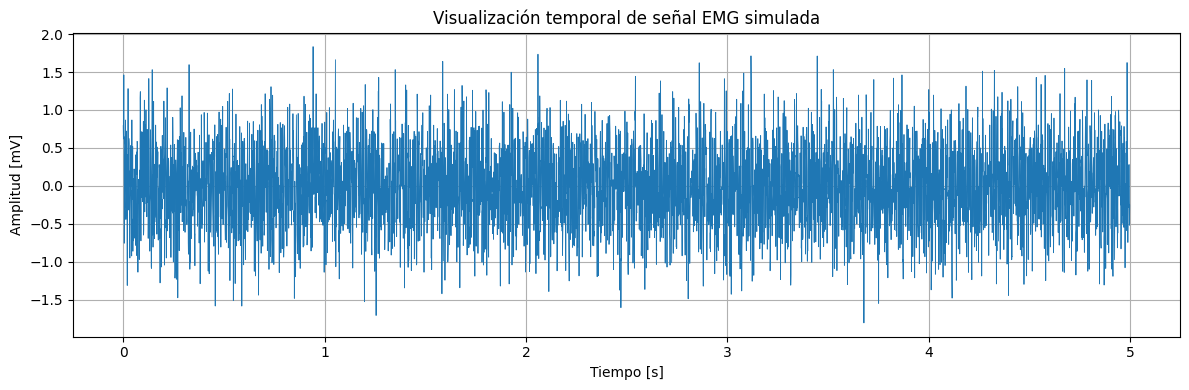

In [ ]:
# Gráfica de la señal EMG

plt.figure(figsize=(12, 4))
plt.plot(t, emg, linewidth=0.6) # Para apreciar mejor la señal, se ajusta el grosor de la línea a 0.6
plt.title("Visualización temporal de señal EMG simulada")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [mV]")
plt.grid(True)
plt.tight_layout()
plt.savefig("Figures/emg_temporal.png", dpi=300) # Guarda en la carpeta "Figures".
plt.show()

In [10]:
# Cálculo de métricas básicas
# Se incluyen datos estadísticos y energéticos de la señal EMG


amplitud_max   = np.max(emg)    # Valor máximo de la señal
amplitud_min   = np.min(emg)    # Valor mínimo de la señal
media          = np.mean(emg)   # Valor promedio de la señal
std            = np.std(emg)    # Desviación estándar de la señal
energia        = np.sum(emg**2) # Energía de la señal
potencia       = energia / N    # Potencia promedio de la señal, viene dado por energía por unidad de tiempo.

print("Métricas básicas:")
print(f"Amplitud máxima     : {amplitud_max:.4f} mV")
print(f"Amplitud mínima     : {amplitud_min:.4f} mV")
print(f"Media               : {media:.4f} mV")
print(f"Desviación estándar : {std:.4f} mV")
print(f"Energía             : {energia:.4f} mV²")
print(f"Potencia promedio   : {potencia:.6f} mV²")

Métricas básicas:
Amplitud máxima     : 1.8344 mV
Amplitud mínima     : -1.8059 mV
Media               : -0.0066 mV
Desviación estándar : 0.5333 mV
Energía             : 1422.5025 mV²
Potencia promedio   : 0.284501 mV²
